# Masked inpainting with a masking CTMC (`cgm_loss`)

A demo of conditional generation with inpainting using nami's discrete pure-jump generator.

The masking CTMC unmasks one coordinate at a time, and its `jump_step` only ever rewrites coordinates that currently hold the absorbing `MASK` token, already-revealed tokens are absorbing and never touched. So if we start sampling from a state where the observed pixels are already their final values and everything else is `MASK`, the observed pixels are preserved for free: the model simply fills in the holes. That means inpainting needs no change to the sampler and only a base distribution that emits the partially-revealed start state. We add a tiny `PartialMask` (modelled on `nami.AllMask`) and let `TauLeapingSampler` do the rest.
rest.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


plt.style.use(
    'https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-dark.mplstyle'
)

import nami
from nami_toys import make_generator

torch.manual_seed(0)
gen = make_generator(0)

## A structured discrete-image toy

In [2]:
H, W = 12, 12
K = 3                      # data colours {0, 1, 2}
D = H * W                  # 144 token coordinates
SWITCH_P = 0.55            # per-row probability of starting a new band


def make_images(n, generator):
    # Random horizontal-band images, returned as (n, D) long tokens.
    imgs = torch.empty(n, H, W, dtype=torch.long)
    for i in range(n):
        color = int(torch.randint(0, K, (1,), generator=generator))
        for r in range(H):
            if r > 0 and torch.rand(1, generator=generator).item() < SWITCH_P:
                # switch to a different colour so bands are visible
                color = (color + 1 + int(torch.randint(0, K - 1, (1,), generator=generator))) % K
            imgs[i, r, :] = color
    return imgs.reshape(n, D)


X = make_images(4000, gen)        # training tokens, (4000, 144)
X_heldout = make_images(8, gen)   # never seen during training
print("data:", tuple(X.shape), "| tokens in", int(X.min()), "..", int(X.max()))

data: (4000, 144) | tokens in 0 .. 2


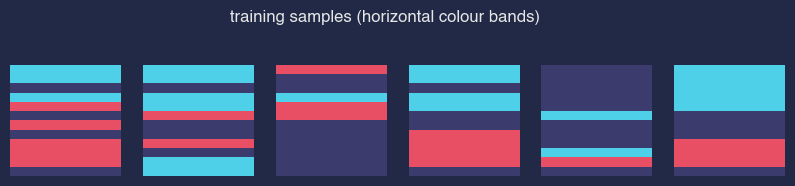

In [3]:
# data colours + grey for the MASK token.
COLORS = ["#3b3b6d", "#e94f64", "#4fd0e9", "#f2c14e"][:K]
MASK_GREY = "#8a8a8a"
CMAP = ListedColormap(COLORS + [MASK_GREY])   # index K == mask -> grey


def show(ax, tokens, title=""):
    grid = tokens.reshape(H, W).cpu().numpy()
    ax.imshow(grid, cmap=CMAP, vmin=0, vmax=K)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])


fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for ax, img in zip(axes, X[:6]):
    show(ax, img)
fig.suptitle("training samples (horizontal colour bands)", y=1.05)
plt.show()

### Train the denoiser with `cgm_loss` (KL)

Standard masking-CTMC setup: the operator adds an absorbing `MASK` token at index `K`, training starts every coordinate masked (`x_noise = full(mask_index)`), and `cgm_loss` automatically picks up the operator's default KL / cross-entropy Bregman divergence on the simplex.

In [4]:
op = nami.CTMCGeneratorOperator(num_states=K, event_shape=(D,))
field = nami.CTMCField(op, hidden=256, layers=4)
interp = nami.MaskingInterpolant(op)
param = nami.generator_prediction(op)               # softmax projection
opt = torch.optim.Adam(field.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=2500)

print("mask_index:", op.mask_index, "| default divergence:", op.default_divergence())

losses = []
for step in range(2500):
    idx = torch.randint(0, len(X), (256,))
    x_data = X[idx]
    x_noise = torch.full_like(x_data, op.mask_index)
    loss = nami.cgm_loss(
        field,
        x_noise=x_noise, x_data=x_data,
        interpolant=interp,
        parameterization=param,    # divergence=None -> KLDivergence
        eps_t=0.0,
    )
    opt.zero_grad(); loss.backward(); opt.step(); scheduler.step()
    losses.append(loss.item())
    if step % 250 == 0:
        print(f"step {step:4d}  cgm_loss {loss.item():.4f}  lr {scheduler.get_last_lr()[0]:.2e}")
print(f"final     cgm_loss {losses[-1]:.4f}")

mask_index: 3 | default divergence: {'rates': KLDivergence(dim=-1, eps=1e-08)}
step    0  cgm_loss 1.0990  lr 2.00e-03
step  250  cgm_loss 0.1376  lr 1.95e-03
step  500  cgm_loss 0.1081  lr 1.81e-03
step  750  cgm_loss 0.1057  lr 1.59e-03
step 1000  cgm_loss 0.1066  lr 1.31e-03
step 1250  cgm_loss 0.1145  lr 9.99e-04
step 1500  cgm_loss 0.0942  lr 6.90e-04
step 1750  cgm_loss 0.1011  lr 4.11e-04
step 2000  cgm_loss 0.0872  lr 1.90e-04
step 2250  cgm_loss 0.1120  lr 4.86e-05
final     cgm_loss 0.0888


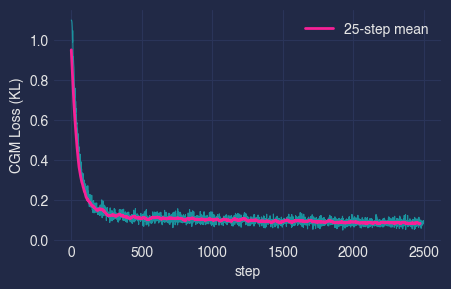

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(losses, lw=0.8, alpha=0.7)
ax.plot(np.convolve(losses, np.ones(25) / 25, mode="valid"), lw=2, label="25-step mean")
ax.set_xlabel("step"); ax.set_ylabel("CGM Loss (KL)"); ax.legend()
plt.show()

### unconditional samples as a sanity check

Sample from the all-`MASK` base (`nami.AllMask`) with `TauLeapingSampler`. If training worked, the samples should look like clean horizontal-band images.

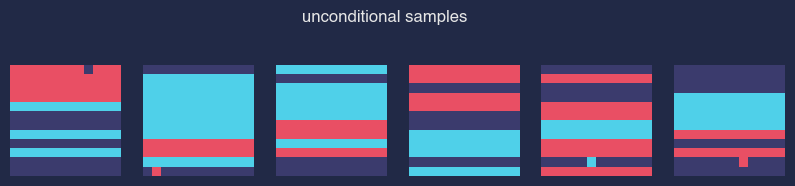

In [6]:
field.eval()
ctmc = nami.GeneratorMatching(
    field, nami.TauLeapingSampler(steps=100),
    parameterization=param,
    base=nami.AllMask((D,), mask_index=op.mask_index),
    event_shape=(D,),
)
with torch.no_grad():
    uncond = ctmc().sample((6,))

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for ax, img in zip(axes, uncond):
    show(ax, img)
fig.suptitle("unconditional samples", y=1.05)
plt.show()
assert (uncond != op.mask_index).all(), "unconditional samples still contain MASK"

### `PartialMask` partially-revealed state

Given a template image `obs` and a boolean `reveal` mask, emits `obs` where revealed and `mask_index` elsewhere, tiled over `sample_shape`. Drawing `sample((N,))` therefore returns N copies of the same masked image, so the N trajectories share the observed context but unmask the hole independently → N diverse completions.

In [7]:
from torch.distributions import Distribution
from torch.types import _size
from nami.core.specs import as_tuple


class PartialMask(Distribution):
    """Base that emits a partially-revealed token state for inpainting.

    Args:
        obs: Template token image, shape ``event_shape`` (long, in ``[0, K)``).
        reveal: Boolean mask, same shape; ``True`` = observed (clamped).
        mask_index: Vocabulary index of the absorbing MASK token.
    """

    has_rsample = False
    arg_constraints: dict = {}

    def __init__(self, obs, reveal, *, mask_index,
                 batch_shape=None, device=None, validate_args=False):
        self.obs = obs.long()
        self.reveal = reveal.bool()
        self.mask_index = int(mask_index)
        self._event_shape_ = tuple(self.obs.shape)
        self._batch_shape_ = as_tuple(batch_shape)
        self.device = device
        # Precompute the start state: obs where revealed, MASK elsewhere.
        self._template = torch.where(
            self.reveal, self.obs, torch.full_like(self.obs, self.mask_index)
        )
        super().__init__(
            batch_shape=torch.Size(self._batch_shape_),
            event_shape=torch.Size(self._event_shape_),
            validate_args=validate_args,
        )

    def sample(self, sample_shape: _size = torch.Size()) -> torch.Tensor:
        shape = tuple(sample_shape) + self._batch_shape_ + self._event_shape_
        return torch.broadcast_to(self._template, shape).clone().to(self.device)

    def expand(self, batch_shape: _size, _instance=None) -> "PartialMask":
        return PartialMask(
            self.obs, self.reveal,
            mask_index=self.mask_index,
            batch_shape=tuple(batch_shape),
            device=self.device,
        )

### Inpainting a held-out image

Take a held-out image and punch a full-width hole through five central rows. Those rows have no observed pixels, so the model is free to invent them.

In [8]:
original = X_heldout[0]                       # (D,) held-out tokens
reveal = torch.ones(D, dtype=torch.bool)
HOLE_ROWS = (4, 5, 6, 7, 8)
for r in HOLE_ROWS:
    reveal[r * W:(r + 1) * W] = False            # hide whole rows -> genuine ambiguity

masked_view = torch.where(reveal, original, torch.full_like(original, op.mask_index))

N = 6
base = PartialMask(original, reveal, mask_index=op.mask_index)
inpainter = nami.GeneratorMatching(
    field, nami.TauLeapingSampler(steps=100),
    parameterization=param,
    base=base,
    event_shape=(D,),
)
with torch.no_grad():
    completions = inpainter().sample((N,))        # (N, D) — same context, N fills
print("completions:", tuple(completions.shape))

completions: (6, 144)


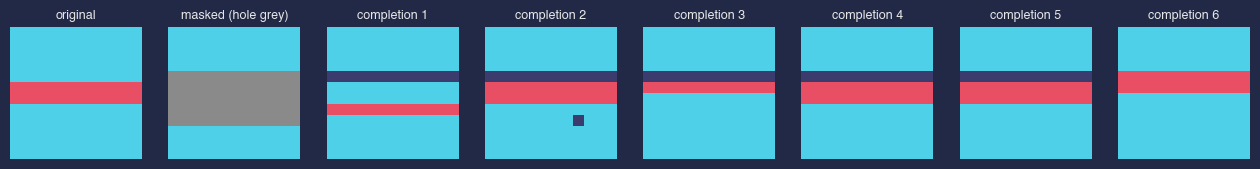

In [9]:
fig, axes = plt.subplots(1, 2 + N, figsize=(2 * (2 + N), 2.2))
show(axes[0], original, "original")
show(axes[1], masked_view, "masked (hole grey)")
for j in range(N):
    show(axes[2 + j], completions[j], f"completion {j + 1}")
plt.show()

The completions share the observed bands above and below the hole but
**differ inside it** — each is a valid stack of horizontal bands, sampled
independently. That is the stochastic unmasking at work: one masked context,
many coherent fills.

### Verification

Three properties must hold:

1. Clamping: completions equal the original exactly at observed positions.
2. Fully unmasked: no `MASK` tokens survive anywhere.
3. Structure: every row of every completion is a single colour (the band structure is respected), and the hole rows actually vary across completions (genuine diversity, not a memorised fill).

In [10]:
obs_idx = reveal                                  # observed coordinates
# clamping: observed pixels are preserved bit-for-bit.
for j in range(N):
    assert torch.equal(completions[j][obs_idx], original[obs_idx]), \
        f"completion {j} altered an observed pixel"

#  no MASK tokens remain.
assert (completions != op.mask_index).all(), "a completion still contains MASK"

# structure: every row is constant within each completion.
rows = completions.reshape(N, H, W)
row_constant = (rows == rows[:, :, :1]).all(dim=-1)        # (N, H)
frac_constant = row_constant.float().mean().item()
assert frac_constant > 0.95, f"rows not solid bands (constant frac={frac_constant:.3f})"

# diversity: the hidden rows differ across the N completions.
hole = rows[:, HOLE_ROWS, 0]                               # (N, |hole rows|) band colours
distinct = {tuple(row.tolist()) for row in hole}
print(f"clamping: OK   no-MASK: OK   row-constant frac: {frac_constant:.3f}")
print(f"distinct hole fills: {len(distinct)} / {N}")
assert len(distinct) >= 2, "completions are not diverse in the hole"
print("all checks passed.")

clamping: OK   no-MASK: OK   row-constant frac: 0.986
distinct hole fills: 4 / 6
all checks passed.
